<a href="https://colab.research.google.com/github/JiHyun13/deeplearning_and_lab_team.5/blob/main/%5B%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_5%EC%A1%B0%5D%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5%ED%95%99%EA%B3%BC_22012137_%EC%9C%A0%EC%A7%80%EC%9D%B8_%EA%B0%9C%EC%9D%B8%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#중간

In [ ]:
# !pip install librosa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, glob
import numpy as np
import ast
import librosa
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
import random

def set_seed(seed: int = 42):
    """
    모든 난수 생성기의 시드를 고정하여 실험의 재현성을 확보합니다.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Seed fixed to {seed} (Python, NumPy, PyTorch)")
set_seed

<function __main__.set_seed(seed: int = 42)>

In [ ]:
import glob, librosa, pandas as pd

file_dir = r"/content/drive/MyDrive/deeplearning/Raw/Audio/WAV_16000/Segmented"
files = glob.glob(os.path.join(file_dir, "*.wav"))
print(f"총 오디오 파일 수: {len(files)}")

총 오디오 파일 수: 2199


In [ ]:
sentiment_meta = r"/content/drive/MyDrive/deeplearning/mosi_audio_metadata.csv"
df = pd.read_csv(sentiment_meta)
df['audio_id2']=df['file_name'].str.replace('.wav','')
print(df.head())

           file_name     audio_id  seg_idx  start_time   end_time  sentiment  \
0  03bSnISJMiM_1.wav  03bSnISJMiM        1   51.904533  55.945350       2.40   
1  03bSnISJMiM_2.wav  03bSnISJMiM        2   56.045124  66.780720      -0.80   
2  03bSnISJMiM_3.wav  03bSnISJMiM        3   66.780720  68.736280      -1.00   
3  03bSnISJMiM_4.wav  03bSnISJMiM        4   68.736280  70.542175      -1.75   
4  03bSnISJMiM_5.wav  03bSnISJMiM        5   70.542175  71.699550       0.00   

       audio_id2  
0  03bSnISJMiM_1  
1  03bSnISJMiM_2  
2  03bSnISJMiM_3  
3  03bSnISJMiM_4  
4  03bSnISJMiM_5  


In [ ]:
## 오디오 파라미터
SR = 16000
n_fft = 512
hop_length = 160
win_length = 400
n_mfcc = 15


def wav_to_feat_vec(wav_path, wav=None):
    if wav is None:
        y, sr = librosa.load(wav_path, sr=SR)
    else:
        y, sr = wav, SR
    yt, idx = librosa.effects.trim(y, top_db=10)
    mfcc = librosa.feature.mfcc(
        y=yt,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        n_mfcc=n_mfcc
    )
    return mfcc.T.astype(np.float32)


In [ ]:
def pad_or_trunc(x, T=1024):
    cur_t, f = x.shape
    if cur_t >= T:
        return x[:T]
    pad = np.zeros((T - cur_t, f), dtype=np.float32)
    return np.vstack([x, pad])

In [ ]:
X, Y = [], []

for _, row in df.iterrows():
    p = os.path.join(file_dir, row["file_name"])
    y = row["sentiment"]

    X.append(wav_to_feat_vec(p))
    Y.append(y)

In [ ]:
X_mlp = np.stack([pad_or_trunc(x) for x in X]).astype(np.float32)
Y_mlp = np.array(Y, dtype=np.float32)

print("X:", X_mlp.shape, "Y:", Y_mlp.shape, "Y range:", Y_mlp.min(), Y_mlp.max())

y_class = (Y_mlp > 0).astype(np.int64)

X: (2199, 1024, 15) Y: (2199,) Y range: -3.0 3.0


In [ ]:
vid_arr = df["audio_id2"].astype(str).to_numpy()

all_vids = np.unique(vid_arr)
vid_rep = np.array([int(y_class[vid_arr == v].mean() >= 0.5) for v in all_vids], dtype=np.int64)

train_vids, test_vids = train_test_split(
    all_vids, test_size=0.2, random_state=42, stratify=vid_rep
)

print(f"Total Videos: {len(all_vids)} | Train: {len(train_vids)} | Test: {len(test_vids)}")

train_mask = np.isin(vid_arr, train_vids)
test_mask  = np.isin(vid_arr, test_vids)

print("vid overlap:", len(set(train_vids) & set(test_vids)))
print("train segs:", train_mask.sum(), "test segs:", test_mask.sum())

X_train, y_train = X_mlp[train_mask], y_class[train_mask]
X_test,  y_test  = X_mlp[test_mask],  y_class[test_mask]

print(f"Final Shapes -> X_train: {X_train.shape}, X_test: {X_test.shape}")

Total Videos: 2199 | Train: 1759 | Test: 440
vid overlap: 0
train segs: 1759 test segs: 440
Final Shapes -> X_train: (1759, 1024, 15), X_test: (440, 1024, 15)


In [ ]:
def aug_noise20(y, snr_db=20):
    noise = np.random.randn(len(y)).astype(np.float32)
    scale = np.sqrt(np.mean(y**2) / (np.mean(noise**2) + 1e-12)) / (10 ** (snr_db / 20))
    y_noise = y + scale * noise
    return y_noise

def aug_pitch_h2(y, sr, steps=2):
    y_pitchShift = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=steps)
    return y_pitchShift

# def aug_noise20p(y, snr_db=20):
#     noise = np.random.randn(len(y)).astype(np.float32)
#     scale = np.sqrt(np.mean(y**2) / (np.mean(noise**2) + 1e-12)) / (10 ** (snr_db / 20))
#     y_noise = y + scale * noise
#     return y_noise

# def aug_pitch_h2(y, sr, steps=2):
#     y_pitchShift = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=steps)
#     return y_pitchShift

def aug_pitch_l2(y, sr, steps=-2):
    y_pitchShift = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=steps)
    return y_pitchShift

def aug_noise20_pitch_h2(y,sr,snr_db=20,steps=2):
    noise = np.random.randn(len(y)).astype(np.float32)
    scale = np.sqrt(np.mean(y**2) / (np.mean(noise**2) + 1e-12)) / (10 ** (snr_db / 20))
    y_noise = y + scale * noise
    y_noise_pitchShift = librosa.effects.pitch_shift(y=y_noise, sr=sr, n_steps=steps)
    return y_noise_pitchShift

def aug_noise20_pitch_l2(y,sr,snr_db=20,steps=-2):
    noise = np.random.randn(len(y)).astype(np.float32)
    scale = np.sqrt(np.mean(y**2) / (np.mean(noise**2) + 1e-12)) / (10 ** (snr_db / 20))
    y_noise = y + scale * noise
    y_noise_pitchShift = librosa.effects.pitch_shift(y=y_noise, sr=sr, n_steps=steps)
    return y_noise_pitchShift

In [ ]:
X_noise20, X_pitch_h2, X_noise20_pitch_h2 =[], [], []
y_noise20, y_pitch_h2, y_noise20_pitch_h2 = [], [], []

for _, row in df[df["audio_id2"].astype(str).isin(train_vids)].iterrows():
    p = os.path.join(file_dir, row["file_name"])
    label = int(row["sentiment"] > 0)
    y, sr = librosa.load(p, sr=None)

    X_noise20.append(pad_or_trunc(wav_to_feat_vec(None, aug_noise20(y))))
    y_noise20.append(label)

    X_pitch_h2.append(pad_or_trunc(wav_to_feat_vec(None, aug_pitch_h2(y,sr))))
    y_pitch_h2.append(label)

X_noise20 = np.stack(X_noise20); y_noise20 = np.array(y_noise20, dtype=np.int64)
X_pitch_h2 = np.stack(X_pitch_h2); y_pitch_h2 = np.array(y_pitch_h2, dtype=np.int64)

KeyboardInterrupt: 

In [ ]:
X_noise20, X_pitch_h2, X_pitch_l2, X_noise20_pitch_h2, X_noise20_pitch_l2 = [], [], [], [], []
y_noise20, y_pitch_h2, y_pitch_l2, y_noise20_pitch_h2, y_noise20_pitch_l2 = [], [], [], [], []

for _, row in df[df["audio_id2"].astype(str).isin(train_vids)].iterrows():
    p = os.path.join(file_dir, row["file_name"])
    label = int(row["sentiment"] > 0)
    y, sr = librosa.load(p, sr=None)


    X_noise20.append(pad_or_trunc(wav_to_feat_vec(None, aug_noise20(y))))
    y_noise20.append(label)

    X_noise20_pitch_h2.append(pad_or_trunc(wav_to_feat_vec(None, aug_noise20_pitch_h2(y,sr))))
    y_noise20_pitch_h2.append(label)

    X_noise20_pitch_l2.append(pad_or_trunc(wav_to_feat_vec(None, aug_noise20_pitch_l2(y,sr))))
    y_noise20_pitch_l2.append(label)

    X_pitch_h2.append(pad_or_trunc(wav_to_feat_vec(None, aug_pitch_h2(y,sr))))
    y_pitch_h2.append(label)

    X_pitch_l2.append(pad_or_trunc(wav_to_feat_vec(None, aug_pitch_l2(y,sr))))
    y_pitch_l2.append(label)

X_noise20 = np.stack(X_noise20); y_noise20 = np.array(y_noise20, dtype=np.int64)
X_noise20_pitch_h2 = np.stack(X_noise20_pitch_h2); y_noise20_pitch_h2 = np.array(y_noise20_pitch_h2, dtype=np.int64)
X_noise20_pitch_l2 = np.stack(X_noise20_pitch_l2); y_noise20_pitch_l2 = np.array(y_noise20_pitch_l2, dtype=np.int64)
X_pitch_h2 = np.stack(X_pitch_h2); y_pitch_h2 = np.array(y_pitch_h2, dtype=np.int64)
X_pitch_l2 = np.stack(X_pitch_l2); y_pitch_l2 = np.array(y_pitch_l2, dtype=np.int64)

In [ ]:
# tag = 'orig'
# X_train_aug = np.concatenate([X_train], axis=0)
# y_train_aug = np.concatenate([y_train], axis=0)

# tag='orig+noise20+pitch_h2'
# X_train_aug = np.concatenate([X_train,X_noise20,X_pitch_h2], axis=0)
# y_train_aug = np.concatenate([y_train,y_noise20,y_pitch_h2], axis=0)

tag = 'orig+noise20+noise20_pitch_h2+noise20_pitch_l2+pitch_h2+pitch_l2'
X_train_aug = np.concatenate([X_train,X_noise20,X_noise20_pitch_h2,X_noise20_pitch_l2,X_pitch_h2,X_pitch_l2], axis=0)
y_train_aug = np.concatenate([y_train,y_noise20,y_noise20_pitch_h2,y_noise20_pitch_l2,y_pitch_h2,y_pitch_l2], axis=0)

print(f"원본: {X_train.shape[0]} → augment 후: {X_train_aug.shape[0]}")

원본: 1759 → augment 후: 10554


In [ ]:
#표준화
N, T, F = X_train_aug.shape
mu = X_train_aug.reshape(-1, F).mean(axis=0)
sd = X_train_aug.reshape(-1, F).std(axis=0) + 1e-8
X_train_z = ((X_train_aug.reshape(-1, F) - mu) / sd).reshape(X_train_aug.shape[0], T, F).astype(np.float32)
X_test_z  = ((X_test.reshape(-1, F) - mu) / sd).reshape(X_test.shape[0], T, F).astype(np.float32)
print(f"Final Shapes -> X_train: {X_train_z.shape}, X_test: {X_test.shape}")

Final Shapes -> X_train: (10554, 1024, 15), X_test: (440, 1024, 15)


In [ ]:
X_tr = torch.tensor(X_train_z, dtype=torch.float32)
X_te = torch.tensor(X_test_z, dtype=torch.float32)
y_tr = torch.tensor(y_train_aug, dtype=torch.long)
y_te = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=256, shuffle=False)

In [ ]:
class LSTM(nn.Module):
  def __init__(self, input_dim=13,hidden_dim=128, num_layers=1, nclass=2):
    super().__init__()
    self.lstm = nn.LSTM(input_size=input_dim,hidden_size=hidden_dim,
                        num_layers=num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_dim, nclass)

  def forward(self, x):
    output, (h_n, c_n) = self.lstm(x)
    h_pool=torch.mean(output, dim=1)
    return self.fc(h_pool)

input_dim=X_train.shape[2]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTM(input_dim=input_dim, hidden_dim=128, nclass=2).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

In [ ]:
def eval_acc(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct / total

In [ ]:
history = {'loss': [], 'train_acc': [], 'test_acc': []}

EPOCH = 30
for epoch in range(EPOCH):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:

        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_acc = eval_acc(model, train_loader)
    test_acc = eval_acc(model,test_loader)

    history['loss'].append(epoch_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

if 'all_results' not in dir():
    all_results = {}

all_results[tag] = {
    'loss': history['loss'],
    'train_acc': history['train_acc'],
    'test_acc': history['test_acc'],
}
print(f"저장 완료: {tag} | 현재 누적: {list(all_results.keys())}")

Epoch 01 | Loss: 0.5635 | Train: 0.7035 | Test: 0.6091
Epoch 02 | Loss: 0.5683 | Train: 0.7150 | Test: 0.6000
Epoch 03 | Loss: 0.5525 | Train: 0.7174 | Test: 0.5795
Epoch 04 | Loss: 0.5524 | Train: 0.7224 | Test: 0.6159
Epoch 05 | Loss: 0.5311 | Train: 0.7383 | Test: 0.5727
Epoch 06 | Loss: 0.5955 | Train: 0.7041 | Test: 0.6091
Epoch 07 | Loss: 0.5628 | Train: 0.7021 | Test: 0.6045
Epoch 08 | Loss: 0.5455 | Train: 0.7100 | Test: 0.6023
Epoch 09 | Loss: 0.5413 | Train: 0.7292 | Test: 0.6023
Epoch 10 | Loss: 0.5240 | Train: 0.7436 | Test: 0.5977
Epoch 11 | Loss: 0.5308 | Train: 0.7302 | Test: 0.6136
Epoch 12 | Loss: 0.5315 | Train: 0.7311 | Test: 0.5932
Epoch 13 | Loss: 0.5326 | Train: 0.7356 | Test: 0.6023
Epoch 14 | Loss: 0.5133 | Train: 0.7601 | Test: 0.5977
Epoch 15 | Loss: 0.5052 | Train: 0.7644 | Test: 0.5932
Epoch 16 | Loss: 0.4878 | Train: 0.7748 | Test: 0.6159
Epoch 17 | Loss: 0.4876 | Train: 0.7527 | Test: 0.5909
Epoch 18 | Loss: 0.4859 | Train: 0.7615 | Test: 0.5886
Epoch 19 |

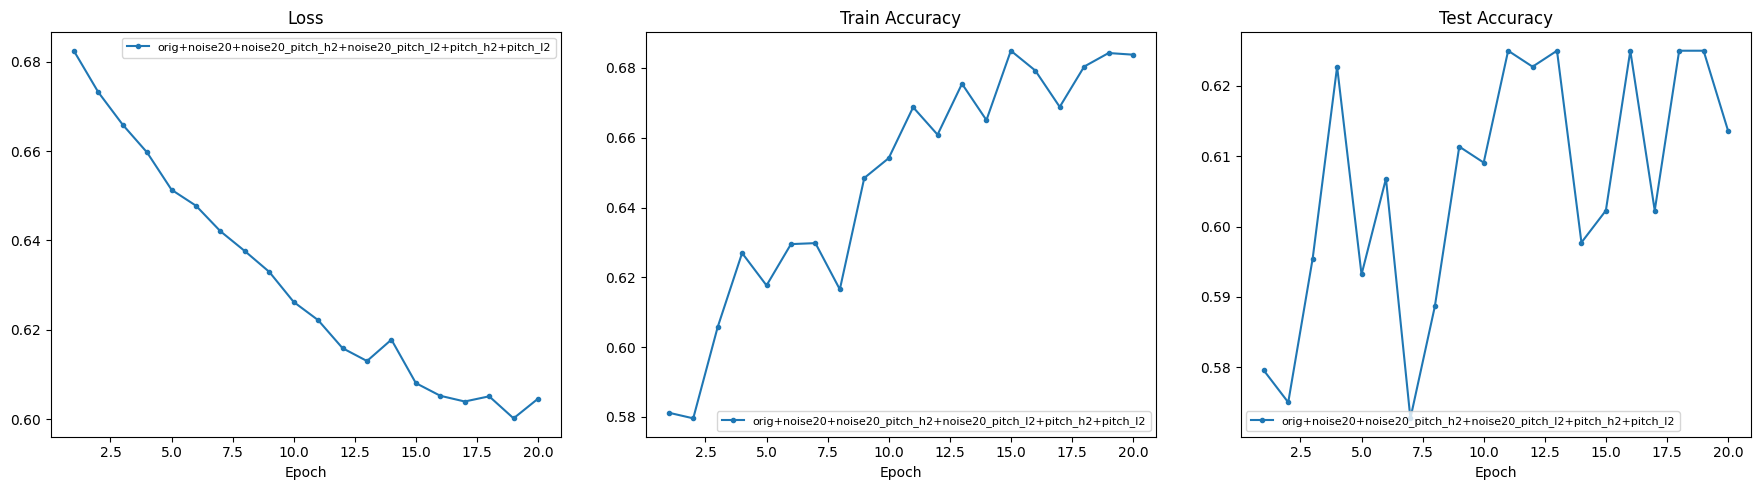

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Loss', 'Train Accuracy', 'Test Accuracy']
keys   = ['loss', 'train_acc', 'test_acc']

for ax, title, key in zip(axes, titles, keys):
    for name, res in all_results.items():
        epochs = range(1, len(res[key]) + 1)
        ax.plot(epochs, res[key], marker='o', markersize=3, label=name)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#베이스라인 코드

In [ ]:
# SR = 16000
# n_mels = 74
# n_fft = 512
# hop_length = 160
# win_length = 400
# n_mfcc = 13

# def wav_to_feat_vecb(wav_path):
#     y, sr = librosa.load(wav_path, sr=SR)

#     mfcc = librosa.feature.mfcc(
#         y=y,
#         sr=sr,
#         n_fft=n_fft,
#         hop_length=hop_length,
#         win_length=win_length,
#         n_mfcc=n_mfcc
#     )


#     mfcc_mean = mfcc.mean(axis=1)
#     mfcc_std = mfcc.std(axis=1)

#     feat = np.concatenate([mfcc_mean, mfcc_std], axis=0).astype(np.float32)
#     return feat

In [ ]:
X_b, Y_b = [], []

for _, row in df.iterrows():
    p = os.path.join(file_dir,row["file_name"])
    y = row["sentiment"]

    X_b.append(wav_to_feat_vecb(p))
    Y_b.append(y)

In [ ]:
X_mlp_b= np.stack(X_b)
Y_mlp_b = np.array(Y_b, dtype=np.float32)

y_class_b = (Y_mlp_b > 0).astype(np.int64)
print("X:", X_mlp_b.shape, "Y:", Y_mlp_b.shape, "Y range:", Y_mlp_b.min(), Y_mlp_b.max())

X: (2199, 26) Y: (2199,) Y range: -3.0 3.0


In [ ]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_mlp_b, y_class_b, test_size=0.2,
    random_state=42, stratify=y_class
)

print(f"Train_data: {len(X_train_b)} | Test_data: {len(X_test_b)}")

Train_data: 1759 | Test_data: 440


In [ ]:
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train_b)
X_test_scaled = scaler.transform(X_test_b)
print(f"Final Shapes -> X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")

Final Shapes -> X_train: (1759, 26), X_test: (440, 26)


In [ ]:
X_tr_b = torch.tensor(X_train_scaled, dtype=torch.float32)
X_te_b = torch.tensor(X_test_scaled, dtype=torch.float32)
y_tr_b = torch.tensor(y_train_b, dtype=torch.long)
y_te_b = torch.tensor(y_test_b, dtype=torch.long)

train_loader_b = DataLoader(TensorDataset(X_tr_b, y_tr_b), batch_size=64, shuffle=True)
test_loader_b = DataLoader(TensorDataset(X_te_b, y_te_b), batch_size=256, shuffle=False)

In [ ]:
class MLP(nn.Module):
  def __init__(self, in_dim, hidden=8, nclass=2):
    super().__init__()

    self.net = nn.Sequential(
        nn.Linear(in_dim, hidden),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(hidden, hidden//2),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(hidden//2,nclass),
    )

  def forward(self, x):
    return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_b = MLP(X_train_b.shape[1]).to(device)
opt = torch.optim.Adam(model_b.parameters(), lr =1e-3)
crit = nn.CrossEntropyLoss()

tag='base'

In [ ]:
def eval_acc_b(loader):
  model_b.eval()
  correct = total =0
  with torch.no_grad():
    for x_batch, y_batch in loader:
      xb, yb = x_batch.to(device), y_batch.to(device)
      pred = model_b(xb).argmax(dim=1)
      correct += (pred ==yb).sum().item()
      total += yb.numel()
  return correct / total

In [ ]:
history = {'loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, 21):

    model_b.train()
    running_loss =0.0
    for x_batch, y_batch in train_loader_b:

      xb, yb = x_batch.to(device), y_batch.to(device)
      opt.zero_grad()
      loss = crit(model_b(xb), yb)
      loss.backward()
      opt.step()

      running_loss += loss.item()


    epoch_loss = running_loss / len(train_loader_b)
    train_acc = eval_acc_b(train_loader_b)
    test_acc = eval_acc_b(test_loader_b)

    history['loss'].append(epoch_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

if 'all_results' not in dir():
    all_results = {}

all_results[tag] = {
    'loss': history['loss'],
    'train_acc': history['train_acc'],
    'test_acc': history['test_acc'],
}
print(f"저장 완료: {tag} | 현재 누적: {list(all_results.keys())}")

Epoch 01 | Loss: 0.7149 | Train: 0.5088 | Test: 0.5091
Epoch 02 | Loss: 0.7085 | Train: 0.5088 | Test: 0.5091
Epoch 03 | Loss: 0.7032 | Train: 0.5088 | Test: 0.5091
Epoch 04 | Loss: 0.7013 | Train: 0.5088 | Test: 0.5091
Epoch 05 | Loss: 0.6993 | Train: 0.5099 | Test: 0.5091
Epoch 06 | Loss: 0.7008 | Train: 0.5094 | Test: 0.5091
Epoch 07 | Loss: 0.6975 | Train: 0.5105 | Test: 0.5068
Epoch 08 | Loss: 0.6928 | Train: 0.5122 | Test: 0.5091
Epoch 09 | Loss: 0.6963 | Train: 0.5190 | Test: 0.5068
Epoch 10 | Loss: 0.6922 | Train: 0.5270 | Test: 0.5091
Epoch 11 | Loss: 0.6895 | Train: 0.5406 | Test: 0.5250
Epoch 12 | Loss: 0.6841 | Train: 0.5628 | Test: 0.5455
Epoch 13 | Loss: 0.6914 | Train: 0.5651 | Test: 0.5432
Epoch 14 | Loss: 0.6936 | Train: 0.5759 | Test: 0.5591
Epoch 15 | Loss: 0.6907 | Train: 0.5804 | Test: 0.5614
Epoch 16 | Loss: 0.6869 | Train: 0.6003 | Test: 0.5773
Epoch 17 | Loss: 0.6928 | Train: 0.5884 | Test: 0.5750
Epoch 18 | Loss: 0.6875 | Train: 0.5867 | Test: 0.5614
Epoch 19 |